In [9]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import scipy.ndimage as ndi
from astropy.stats import sigma_clip

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.backends.backend_pdf as mpdf
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist

from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from itertools import product
from helpers2 import *

%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
####List files in directory

model_dir='/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/ModelsMaps/finishedModels2/'
fit_dir = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'
files_in_directory = os.listdir(model_dir)


with open('injected-model-list.txt', 'w') as file:
    for filename in files_in_directory:
        file.write(filename + '\n')
files = [f for f in files_in_directory if os.path.isfile(os.path.join(model_dir, f))]
directory_count = sum(os.path.isdir(os.path.join(fit_dir, d)) for d in os.listdir(fit_dir))
print(f"Number of Model Files: {len(files)}")
print(f"Number of Model Directory: {directory_count}")

num = 1
run_numbers = np.linspace(1, 249, 249)
for run_number in run_numbers:
    try:
        catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
        fitted_sources = parse_yaml_file(catalog_results)
    except FileNotFoundError:
        num = num+1
        skip_val = 1
print(f'Total Number of Fits with no Final Refit: {num} and with Final Refit: {directory_count-num}')

run_number = 211
save_pdf=False

outdir = os.getcwd()+ '/simplots/'
if not os.path.exists(outdir):
    os.makedirs(outdir)

if save_pdf:
    from matplotlib.backends.backend_pdf import PdfPages
    pdf = PdfPages(os.path.join(outdir, f'run-{run_number}-plots.pdf')) 

run_number_str = str(run_number)
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

injected_model_yaml = "injected-model-list.txt"
with open(injected_model_yaml, 'r') as filelist:
    lines=filelist.readlines()

ra_list=[]
dec_list = []
run_number_list = []
for i, run in enumerate(lines):
    run = run.strip()
    ra,dec = extract_ra_dec(run)
    run_number2 = extract_run(run)
    ra_list.append(ra)
    dec_list.append(dec)
    run_number_list.append(int(run_number2))

run_index = run_number_list.index(run_number)
ra_center = ra_list[run_index]
dec_center = dec_list[run_index]
ra_center = "{:.2f}".format(float(ra_center))
dec_center = "{:.2f}".format(float(dec_center))
model_file = model_dir + 'model_'+str(int(run_number))+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'
print(model_file)

injected_sources = parse_yaml_file(model_file)
inj_names = [source['source_name'] for source in injected_sources]
ra_vals = [source['lon0'] for source in injected_sources]
dec_vals = [source['lat0'] for source in injected_sources]
ext_vals = [source['sigma'] for source in injected_sources]
print(injected_sources)

try:
    catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
    fitted_sources = parse_yaml_file(catalog_results)
    rec_names = [source['source_name'] for source in fitted_sources]
    rec_ra_vals = [source['lon0'] for source in fitted_sources]
    rec_dec_vals = [source['lat0'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]
except:
    print("No ALPS Final result")
    catalog_results = f"{fit_dir}model_{int(run_number)}/models/curModel.model"
    fitted_sources = parse_model_file(catalog_results)
    rec_names = [source['name'] for source in fitted_sources]
    rec_ra_vals = [source['ra'] for source in fitted_sources]
    rec_dec_vals = [source['dec'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]

fig, ax = plt.subplots(figsize=(8.5, 11)) 
ax.axis('off') 
text = f"DRIPS Compilation of Result for Simulation Run {run_number} with (RA, Dec) = ({ra_center}, {dec_center})"
ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
if save_pdf:
    pdf.savefig(fig)  
plt.close(fig)

injected_sources = pd.DataFrame({
    "Name": inj_names, 
    "ra": ra_vals,
    "dec":  dec_vals, 
    "ext": ext_vals,
    })
alps_sources = pd.DataFrame({
    "Name": rec_names, 
    "ra": rec_ra_vals , 
    "dec":  rec_dec_vals, 
    "ext": rec_ext_vals
    })

Number of Model Files: 249
Number of Model Directory: 249
Total Number of Fits with no Final Refit: 102 and with Final Refit: 147
/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/ModelsMaps/finishedModels2/model_211_roi_150.28_33.32.yaml
[{'source_name': 'source_0 (extended source)', 'lon0': 151.4504961932792, 'lat0': 33.55515494181991, 'sigma': 0.4650353071876583}, {'source_name': 'source_1 (point source)', 'lon0': 150.5008003214179, 'lat0': 35.18165604527394, 'sigma': 0}, {'source_name': 'source_2 (point source)', 'lon0': 149.10651065850104, 'lat0': 34.55997276146646, 'sigma': 0}, {'source_name': 'source_3 (extended source)', 'lon0': 152.0141626499946, 'lat0': 34.54604527132376, 'sigma': 1.442235200093136}]


In [11]:

with open(model_file, 'r') as file:
    data = yaml.safe_load(file)

CU = 6.13e-21
sources = []
for source, properties in data.items():
    if 'Gaussian_on_sphere' in properties:
        print(properties['Gaussian_on_sphere'])
        print(np.abs(properties['spectrum']['main']['Powerlaw']['index']['value']))
        print(properties['spectrum']['main']['Powerlaw']['K']['value']/CU)
        print(properties['Gaussian_on_sphere'].get('sigma', {}).get('value', None))
        # print(properties['spectrum']['index'])
    elif 'position' in properties:
        print(properties['position'])
        print(np.abs(properties['spectrum']['main']['Powerlaw']['index']['value']))
        print(properties['spectrum']['main']['Powerlaw']['K']['value']/CU)
    # if 'Gaussian_on_sphere' in properties:
    #     lon0 = properties['Gaussian_on_sphere']['lon0']['value']
    #     lat0 = properties['Gaussian_on_sphere']['lat0']['value']
    #     sigma = properties['Gaussian_on_sphere'].get('sigma', {}).get('value', None)
    #     sources.append({
    #         'source_name': source,
    #         'lon0': lon0,
    #         'lat0': lat0,
    #         'sigma': sigma,
    #         # 'spectrum': spectrum,
    #         # 'index' : index
    #     })
    # elif 'position' in properties:
    #     lon0 = properties['position']['ra']['value']
    #     lat0 = properties['position']['dec']['value']
    #     sigma = 0
    #     sources.append({
    #         'source_name': source,
    #         'lon0': lon0,
    #         'lat0': lat0,
    #         'sigma': sigma,
    #     })
    # else:
    #     pass

{'lon0': {'value': 151.4504961932792, 'desc': 'Longitude of the center of the source', 'min_value': 0.0, 'max_value': 360.0, 'unit': 'deg', 'is_normalization': False, 'delta': 0.1, 'free': False}, 'lat0': {'value': 33.55515494181991, 'desc': 'Latitude of the center of the source', 'min_value': -90.0, 'max_value': 90.0, 'unit': 'deg', 'is_normalization': False, 'delta': 0.1, 'free': False}, 'sigma': {'value': 0.4650353071876583, 'desc': 'Standard deviation of the Gaussian distribution', 'min_value': 0.0, 'max_value': 20.0, 'unit': 'deg', 'is_normalization': False, 'delta': 1.0, 'free': False}}
2.8507485557160104
0.0722444496323537
0.4650353071876583
{'ra': {'value': 150.5008003214179, 'desc': 'Right Ascension', 'min_value': 0.0, 'max_value': 360.0, 'unit': 'deg', 'is_normalization': False, 'delta': 15.050080032141791, 'free': False}, 'dec': {'value': 35.18165604527394, 'desc': 'Declination', 'min_value': -90.0, 'max_value': 90.0, 'unit': 'deg', 'is_normalization': False, 'delta': 3.5181

In [12]:
# Load the Simulation FITS file
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

print(f"ROI center {ra_center}, {dec_center}")
model_file = model_dir + '/model_'+str(run_number)+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'

ra_center = float("{:.2f}".format(float(ra_center)))
dec_center = float("{:.2f}".format(float(dec_center)))
coord_sys = 'C'
xlength=5
ylength=5

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, ra_center, dec_center, xlength, ylength, coord_sys)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)

ROI center 150.28, 33.32
ROI center in Celestial Coordintes = 150.28, 33.32
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 150.28 33.32 
CRPIX : 900.0 900.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1800  1800


Fits File loaded
Degrees per pixel: 0.005555555555555556 
Shape of Map in pixel number: 1800 X 1800
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (1145, 1050)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (149.14884248, 34.54541545)>
Peak intensity value: 25.684832233435216
None


Plotting contours [7, 9, 12, 13, 14, 15]


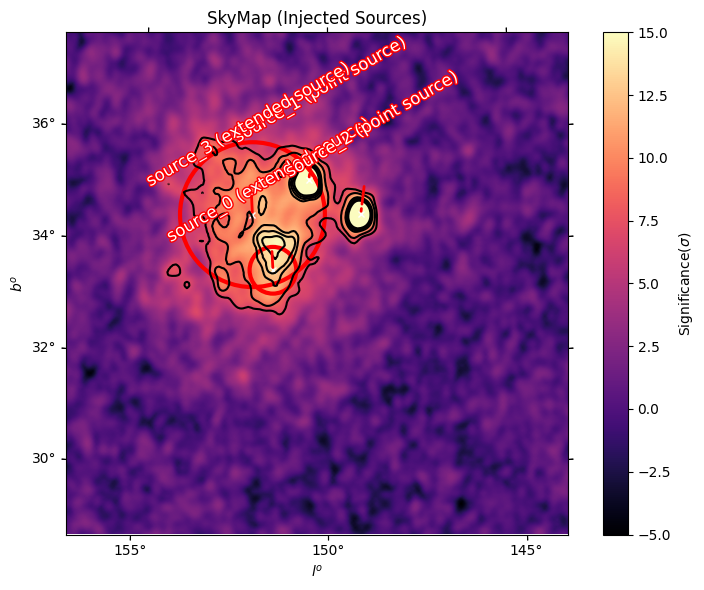

In [13]:
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title=f'SkyMap (Injected Sources)', hotspots=injected_sources, save_dir=None, pdf=False, cmap='magma', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])

Plotting contours [7, 9, 12, 13, 14, 15]


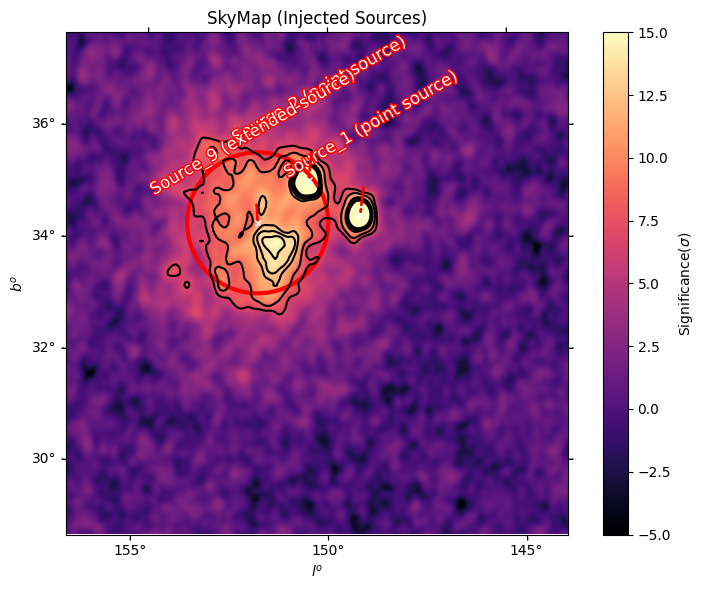

In [14]:
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title=f'SkyMap (Injected Sources)', hotspots=alps_sources, save_dir=None, pdf=False, cmap='magma', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])

Min significance in Loaded Map= -5.169506207957346
Max significance in Loaded Map= 25.684832233435216
Image softly floored to -5 sigma


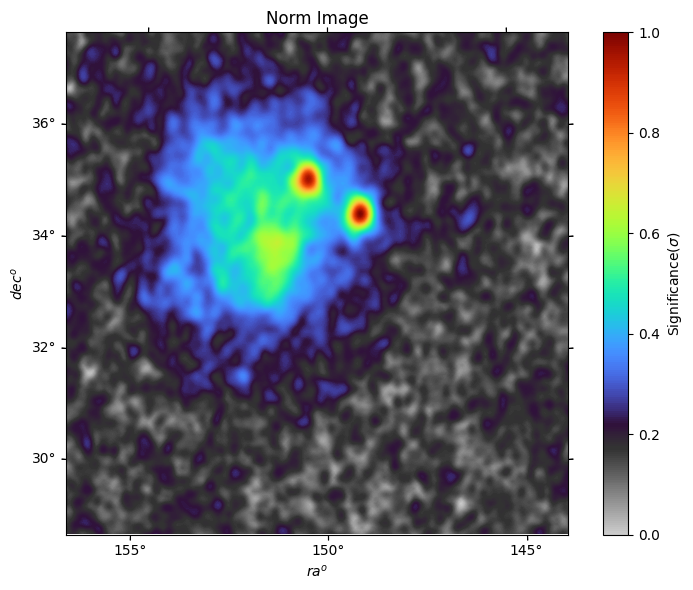

In [15]:
print("Min significance in Loaded Map=",np.min(array))
print("Max significance in Loaded Map=",np.max(array))
if np.min(array) < -5:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

# #Normalize the image between 0 and 1 for analysis
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6)) 


In [16]:
all_ps_blobs = []
all_pscoord_blobs = []
all_psradius_blobs = []

all_ext_blobs = []
all_extcoord_blobs = []
all_extradius_blobs = []

def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])


def run_ps(dog_final, pixel_size, threshold_val):
    return blob_dog(dog_final, 
                    min_sigma=0.2/pixel_size,
                    max_sigma=0.39/pixel_size,
                    threshold=threshold_val,
                    exclude_border=50,
                    overlap=0.7)

def run_ext(extmap, pixel_size, threshold_val):
    return blob_dog(extmap, 
                    min_sigma=0.5/pixel_size,
                    max_sigma=1/pixel_size,
                    threshold=threshold_val,
                    exclude_border=50,
                    overlap=0.7)

Processing Radii:   0%|          | 0/4 [00:00<?, ?it/s]

Number of pixels corresponding to 0.25 smear radius = 45.00
Estimated background RMS: 0.025656004456585398
Raw blobs — point source: 5, extended: 2
Sources after 5σ filtering: 5


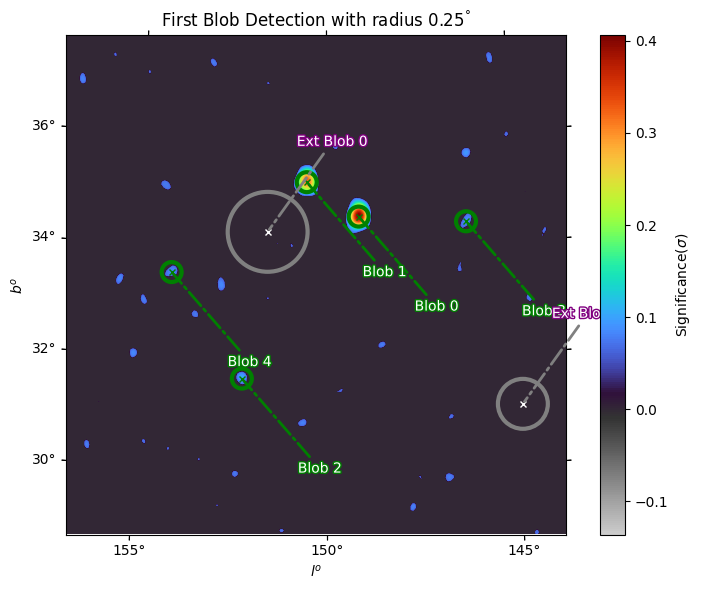

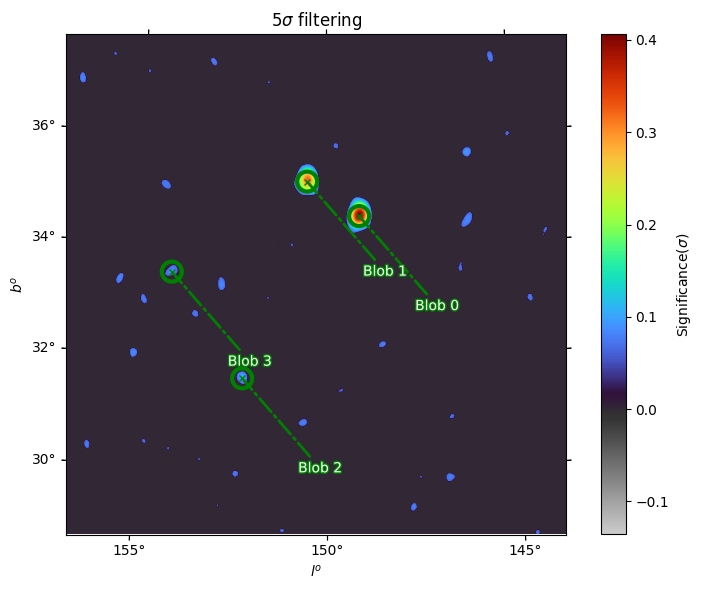

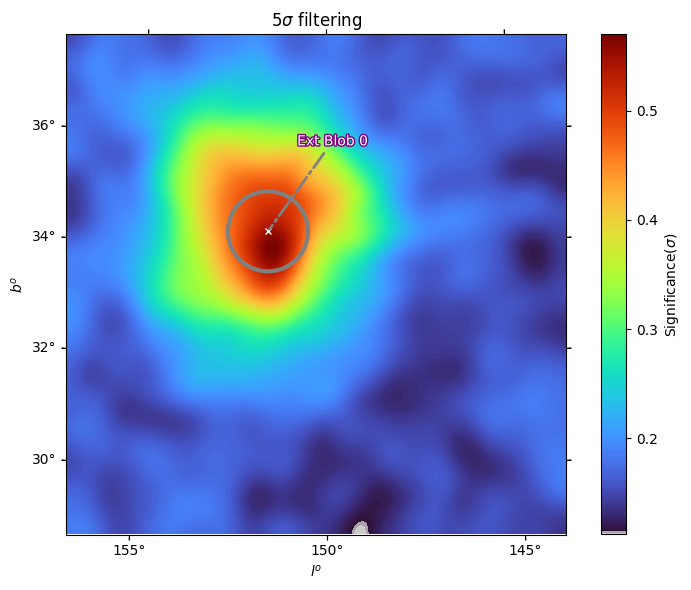

Processing Radii:  25%|██▌       | 1/4 [00:14<00:42, 14.05s/it]

Number of pixels corresponding to 0.30 smear radius = 54.00
Estimated background RMS: 0.02766975934239128
Raw blobs — point source: 5, extended: 2
Sources after 5σ filtering: 5


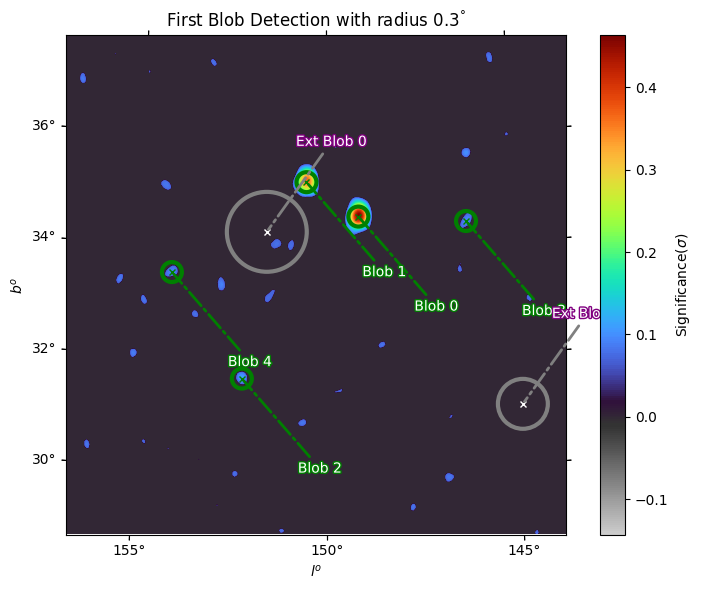

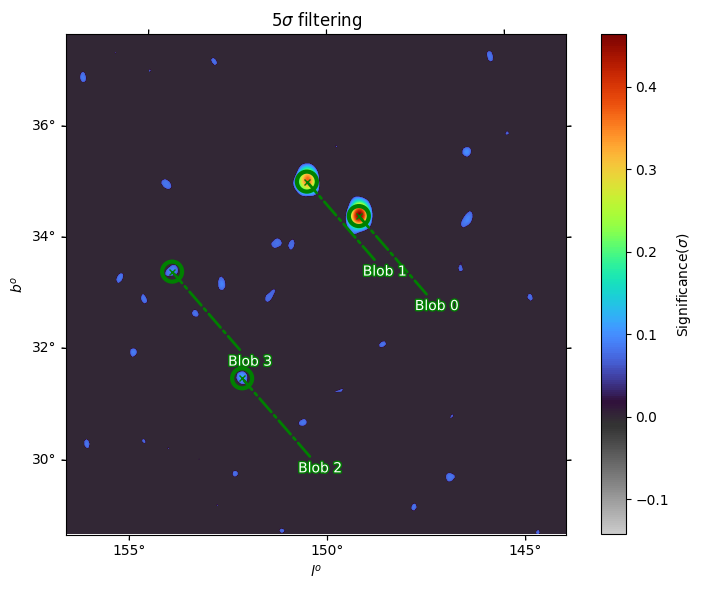

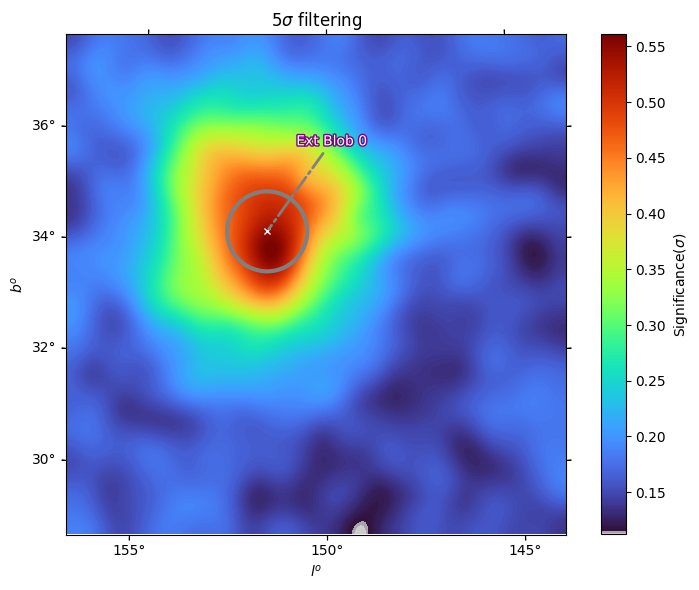

Processing Radii:  50%|█████     | 2/4 [00:28<00:28, 14.19s/it]

Number of pixels corresponding to 0.40 smear radius = 72.00
Estimated background RMS: 0.03034857665978897
Raw blobs — point source: 7, extended: 2
Sources after 5σ filtering: 7


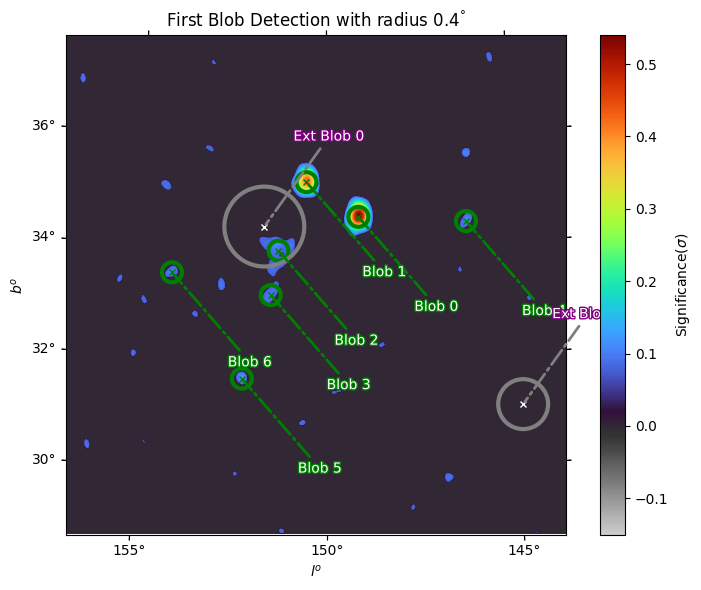

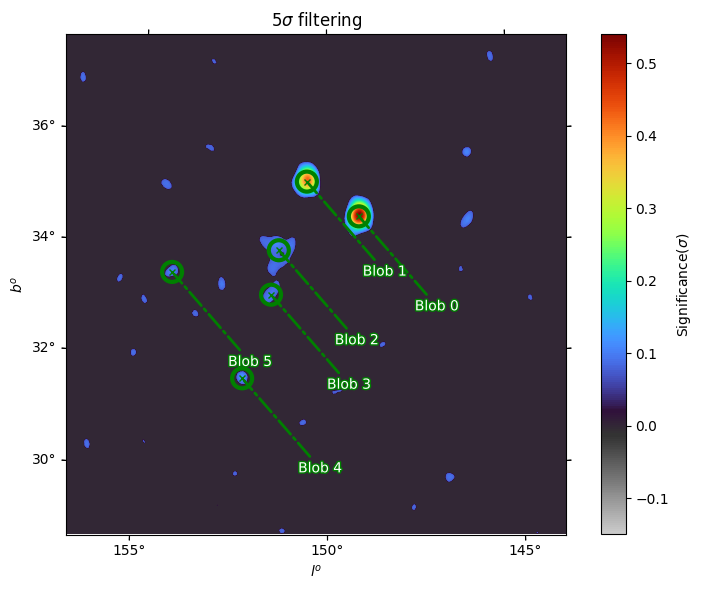

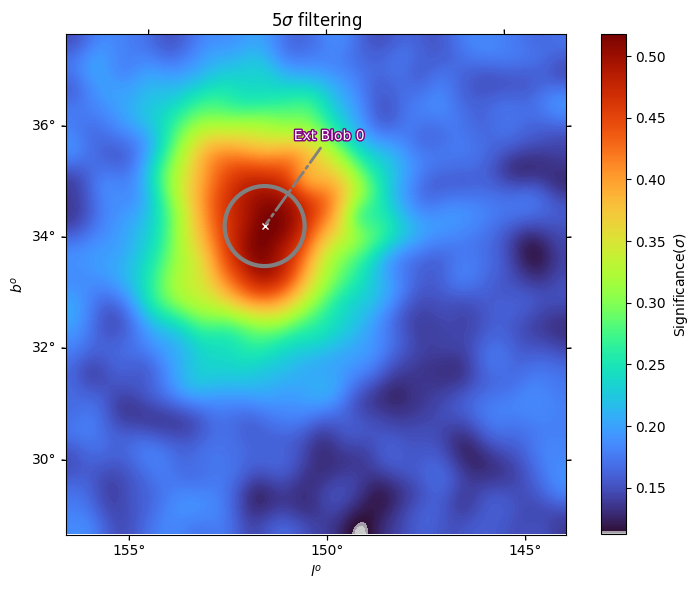

Processing Radii:  75%|███████▌  | 3/4 [00:43<00:14, 14.54s/it]

Number of pixels corresponding to 0.50 smear radius = 90.00
Estimated background RMS: 0.03164691796196092
Raw blobs — point source: 8, extended: 2
Sources after 5σ filtering: 8


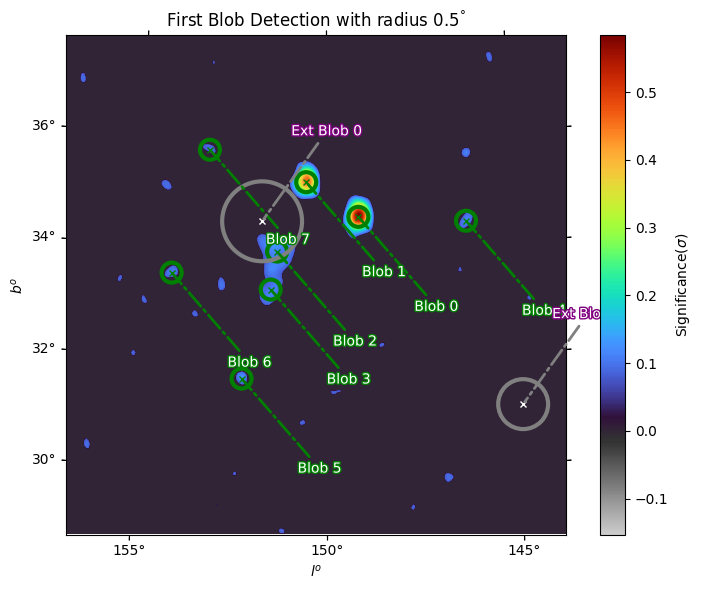

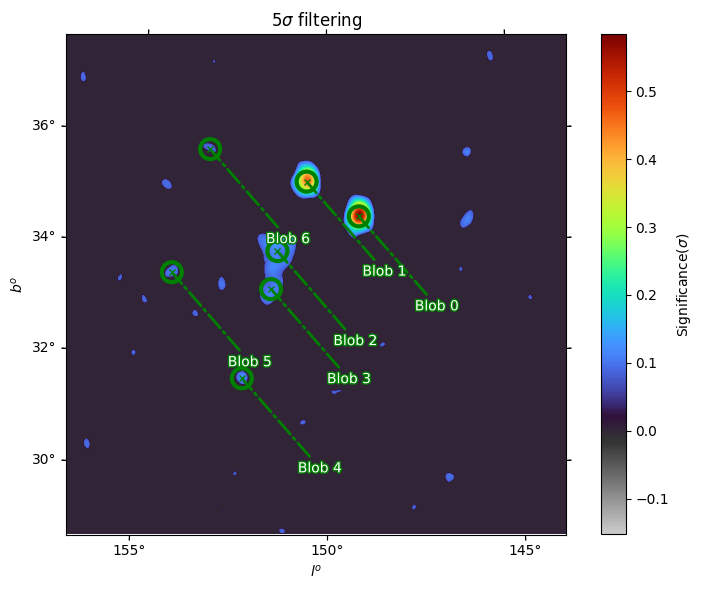

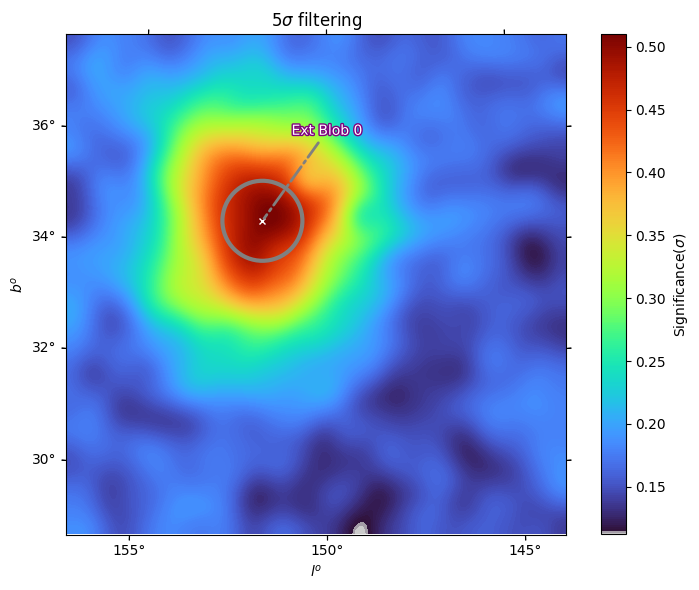

Processing Radii: 100%|██████████| 4/4 [00:58<00:00, 14.66s/it]


In [ ]:
diagnostics=True
for radius in tqdm([0.25, 0.3,  0.4, 0.5], desc='Processing Radii'):
    smear_radius=radius
    pixel_smear = smear_radius/pixel_size

    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {pixel_smear:.2f}")

    dog_image = difference_of_gaussians(norm_image, 1, pixel_smear)
    sigma_resid = estimate_background_sigma(dog_image)
    print("Estimated background RMS:", sigma_resid)

    dog_final = np.where(dog_image > 2.5 * sigma_resid, dog_image, 0)
    dog_norm = (dog_final-np.min(dog_final))/(np.max(dog_final)-np.min(dog_final))
    extmap=gaussian_filter(norm_image-dog_norm, sigma=0.3/pixel_size)

    if np.max(array) > 100:
        threshold_val = 0.001
    else:
        threshold_val = 0.01
    with ThreadPoolExecutor(max_workers=2) as ex:
        f_ps  = ex.submit(run_ps,  dog_final, pixel_size, threshold_val)
        f_ext = ex.submit(run_ext, extmap,    pixel_size, threshold_val)

    ps_blobs, ext_blobs = f_ps.result(), f_ext.result()

    print(f"Raw blobs — point source: {len(ps_blobs)}, extended: {len(ext_blobs)}")

    if diagnostics:
        blobs_dict = {'psblobs': ps_blobs, 'extblobs': ext_blobs}
        fig, ax = make_plots(
            dog_final, wcs, pixel_size,
            coordsys='G', threshold=0.005, hotspots=None,
            blobs=blobs_dict,
            vmin=dog_image.min(), vmax=dog_image.max(),
            title=f'First Blob Detection with radius {smear_radius}$^\\degree$',
            cmap='ult', labels=['4haawc'],
        )

    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, array,5 , wcs, pixel_size)
    ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, array,5 , wcs, pixel_size)

    print(f"Sources after 5σ filtering: {len(ps_filtered_blobs) + len(ext_filtered_blobs)}")

    fig, ax = make_plots(
        dog_final, wcs, pixel_size,
        coordsys='G', threshold=0.005, hotspots=None,
        blobs={'psblobs': ps_filtered_blobs},
        vmin=dog_image.min(), vmax=dog_image.max(),
        title=r'5$\sigma$ filtering', cmap='ult', labels=['4haawc'],
    )
    fig, ax = make_plots(
        extmap, wcs, pixel_size,
        coordsys='G', threshold=0.005, hotspots=None,
        blobs={'extblobs': ext_filtered_blobs},
        vmin=extmap.min(), vmax=extmap.max(),
        title=r'5$\sigma$ filtering', cmap='ult', labels=['4haawc'],
    )
    plt.show()

    if save_pdf:
        pdf.savefig(fig)

    if len(ps_filtered_blobs) > 0:
        all_ps_blobs.append(ps_filtered_blobs)
        all_pscoord_blobs.append(ps_filtered_coords)
        all_psradius_blobs.append(ps_filtered_radius)

    if len(ext_filtered_blobs) > 0:
        all_ext_blobs.append(ext_filtered_blobs)
        all_extcoord_blobs.append(ext_filtered_coords)
        all_extradius_blobs.append(ext_filtered_radius)

Point sources   — combined:   56  |  after overlap removal:    7
Extended sources— combined:   12  |  after overlap removal:    1
Point sources   — after 5σ filtering:    7
Extended sources— after 5σ filtering:    1


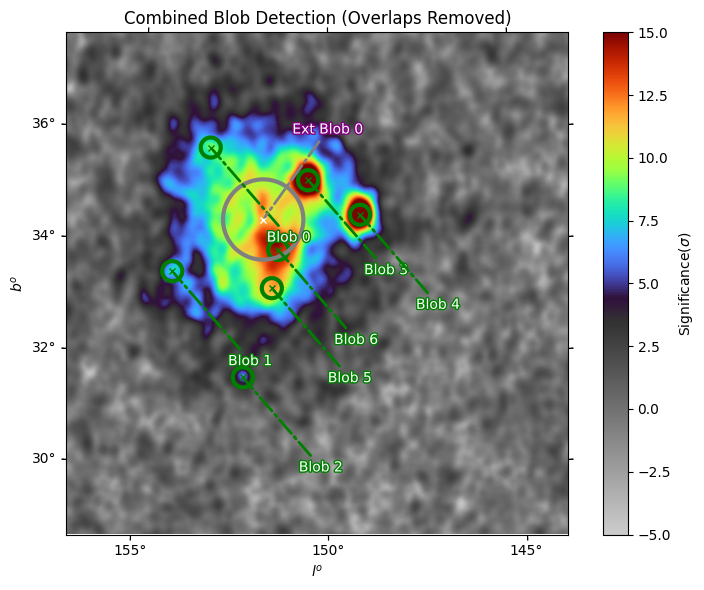

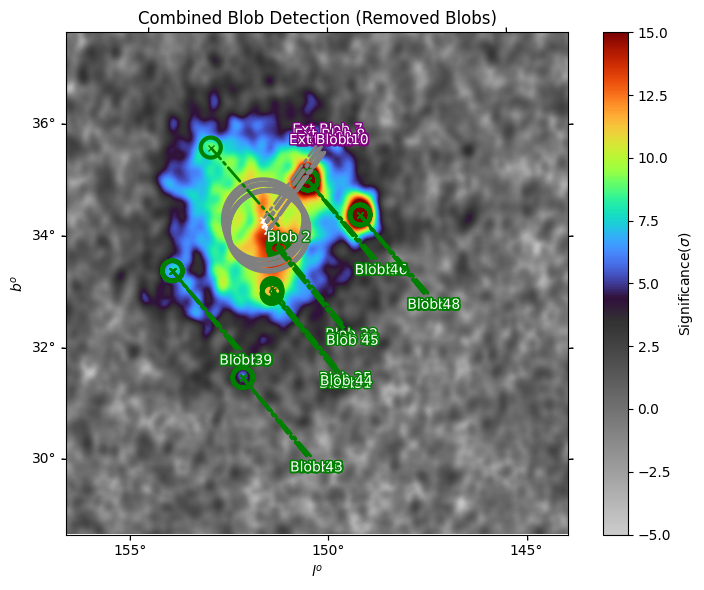

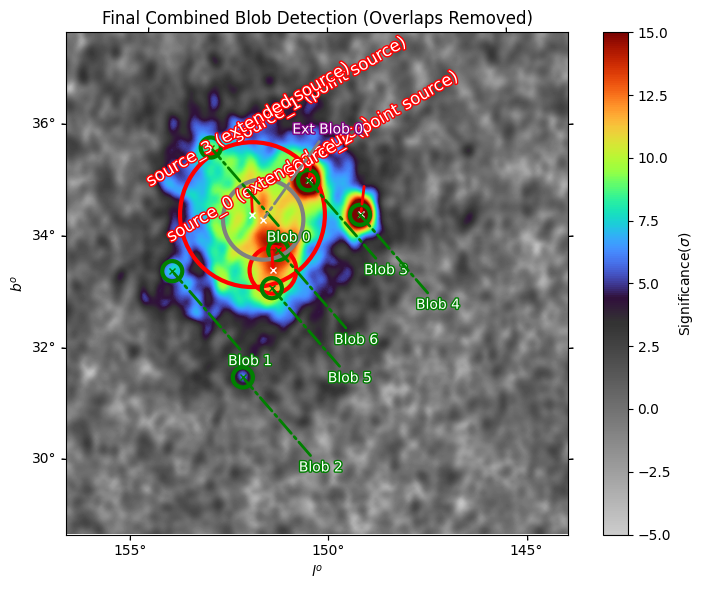

In [ ]:
def combine_blobs(all_blobs, all_coords, all_radii):
    """Flatten per-radius blob lists into single combined arrays."""
    if len(all_blobs) > 0:
        return (
            np.vstack(all_blobs),
            [coord   for sublist in all_coords  for coord   in sublist],
            [radius  for sublist in all_radii   for radius  in sublist],
        )
    return np.empty((0, 3)), [], []

combined_ps_blobs,  combined_ps_coords,  combined_ps_radii  = combine_blobs(all_ps_blobs,  all_pscoord_blobs,  all_psradius_blobs)
combined_ext_blobs, combined_ext_coords, combined_ext_radii = combine_blobs(all_ext_blobs, all_extcoord_blobs, all_extradius_blobs)



final_ps_blobs,  final_ps_coords,  final_ps_radii,  *_ = remove_overlapping_blobs(combined_ps_blobs,  combined_ps_coords,  combined_ps_radii)
final_ext_blobs, final_ext_coords, final_ext_radii, *_ = remove_overlapping_blobs(combined_ext_blobs, combined_ext_coords, combined_ext_radii)

if diagnostics:
    final_ps_blobs,  final_ps_coords,  final_ps_radii, removed_ps_blobs,  removed_ps_coords,  removed_ps_radii = remove_overlapping_blobs(combined_ps_blobs,  combined_ps_coords,  combined_ps_radii)
    final_ext_blobs, final_ext_coords, final_ext_radii, removed_ext_blobs, removed_ext_coords, removed_ext_radii = remove_overlapping_blobs(combined_ext_blobs, combined_ext_coords, combined_ext_radii)

    blobs_dict = {'psblobs': final_ps_blobs, 'extblobs': final_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        title='Combined Blob Detection (Overlaps Removed)',
        cmap='ult',
        labels=['4haawc', 'hgaps'],
    )
    blobs_dict = {'psblobs': removed_ps_blobs, 'extblobs': removed_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        title='Combined Blob Detection (Removed Blobs)',
        cmap='ult',
        labels=['4haawc', 'hgaps'],
    )
    if save_pdf:
        pdf.savefig(fig)

print(f"Point sources   — combined: {len(combined_ps_blobs):>4}  |  after overlap removal: {len(final_ps_blobs):>4}")
print(f"Extended sources— combined: {len(combined_ext_blobs):>4}  |  after overlap removal: {len(final_ext_blobs):>4}")

final_ps_blobs,  final_ps_coords,  final_ps_radii  = blob_filter_intensity(final_ps_blobs,  array, 5, wcs, pixel_size)
final_ext_blobs, final_ext_coords, final_ext_radii = blob_filter_intensity(final_ext_blobs, array, 5, wcs, pixel_size)

print(f"Point sources   — after 5σ filtering: {len(final_ps_blobs):>4}")
print(f"Extended sources— after 5σ filtering: {len(final_ext_blobs):>4}")

if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs, 'extblobs': final_ext_blobs}
    fig, ax = make_plots(
        array, wcs, pixel_size,
        coordsys='G',
        blobs=blobs_dict,
        hotspots=injected_sources,
        title='Final Combined Blob Detection (Overlaps Removed)',
        cmap='ult',
        labels=['4haawc', 'hgaps'],
    )
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot.")

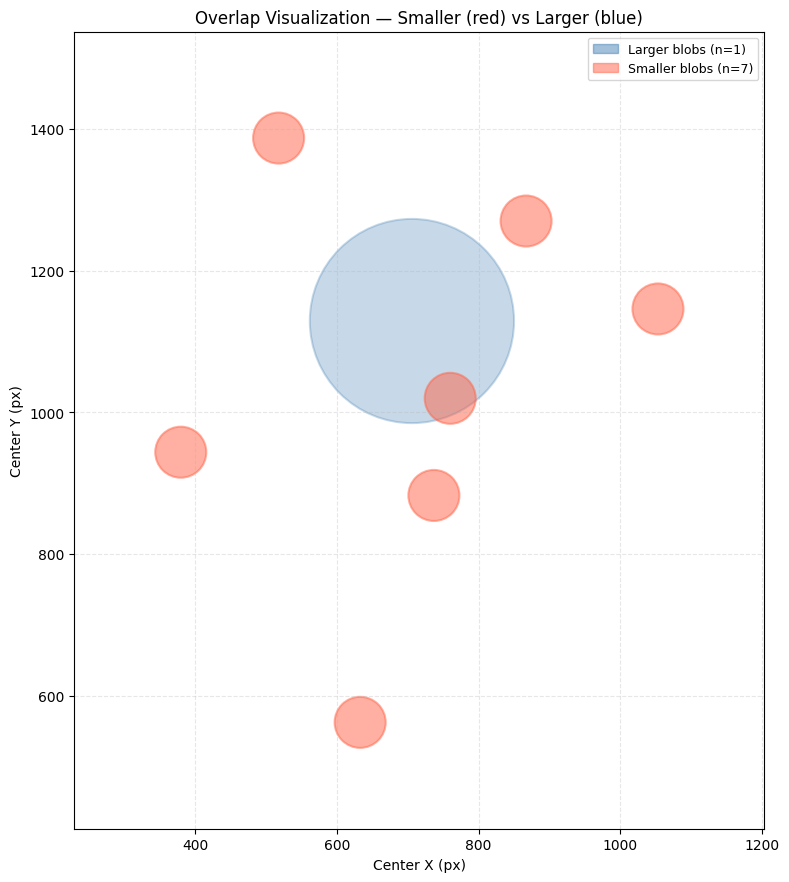

In [ ]:
# ── Safe vstack with fallback for empty arrays ────────────────────────────────
ps_plot  = final_ps_blobs  if len(final_ps_blobs)  > 0 else np.zeros((1, 3))
ext_plot = final_ext_blobs if len(final_ext_blobs) > 0 else np.zeros((1, 3))
all_blobs = np.vstack([ps_plot, ext_plot])

fig, ax = plt.subplots(figsize=(8, 14))

for blob in final_ext_blobs:
    cy, cx, r = blob
    ax.add_patch(patches.Circle((cx, cy), r, linewidth=1.5,
                                 edgecolor='steelblue', facecolor='steelblue', alpha=0.3))

for blob in final_ps_blobs:
    cy, cx, r = blob
    ax.add_patch(patches.Circle((cx, cy), r, linewidth=1.5,
                                 edgecolor='tomato', facecolor='tomato', alpha=0.5))

legend_handles = [
    patches.Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.5,
                  label=f'Larger blobs (n={len(final_ext_blobs)})'),
    patches.Patch(facecolor='tomato',    edgecolor='tomato',    alpha=0.5,
                  label=f'Smaller blobs (n={len(final_ps_blobs)})'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

margin = 150
ax.set_ylim(all_blobs[:, 0].min() - margin, all_blobs[:, 0].max() + margin)
ax.set_xlim(all_blobs[:, 1].min() - margin, all_blobs[:, 1].max() + margin)
ax.set_aspect('equal')
ax.set_xlabel('Center X (px)')
ax.set_ylabel('Center Y (px)')
ax.set_title('Overlap Visualization — Smaller (red) vs Larger (blue)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
groups = []

def overlap_fraction(ly, lx, lr, sy, sx, sr):
    """Fraction of the smaller blob's area that overlaps with the larger blob."""
    dist = np.sqrt((sy - ly)**2 + (sx - lx)**2)
    if dist >= lr + sr:
        return 0.0
    if dist + sr <= lr:
        return 1.0

    r, R = sr, lr   # small, large radii
    d    = dist

    alpha = np.arccos((d**2 + r**2 - R**2) / (2 * d * r))  # half-angle at small circle center
    beta  = np.arccos((d**2 + R**2 - r**2) / (2 * d * R))  # half-angle at large circle center

    intersection = r**2 * alpha + R**2 * beta - 0.1 * (r**2 * np.sin(2*alpha) + R**2 * np.sin(2*beta))
    small_area   = np.pi * r**2

    return intersection / small_area


groups = []
matched_ps = set()

for lb in final_ext_blobs:
    ly, lx, lr = lb
    matched = []
    for i, sb in enumerate(final_ps_blobs):
        sy, sx, sr = sb
        frac = overlap_fraction(ly, lx, lr, sy, sx, sr)
        if frac > 0.5:
            matched.append((sb, frac))
            matched_ps.add(i)
    groups.append((lb, matched))

for i, sb in enumerate(final_ps_blobs):
    if i not in matched_ps:
        groups.append((None, [(sb, 0.0)]))

Plotting larger blob at (706, 1129) with radius 144.0px and center intensity 11.53
    Plotting smaller blob at (760, 1020) with radius 36.0px and center intensity 14.26 — overlap/touch with larger blob


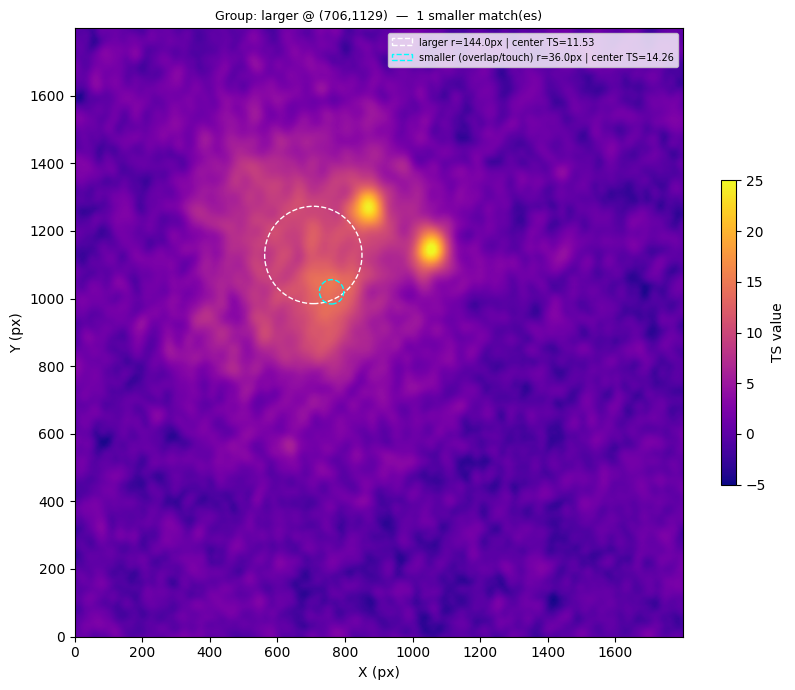

Plotting larger blob at (518, 1387) with radius 36.0px and center intensity 9.03


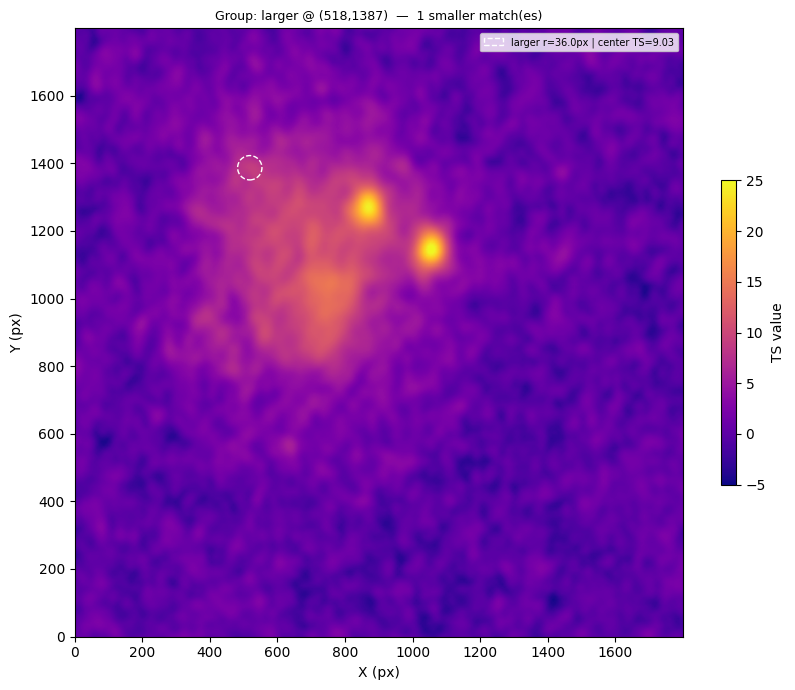

Plotting larger blob at (380, 944) with radius 36.0px and center intensity 7.62


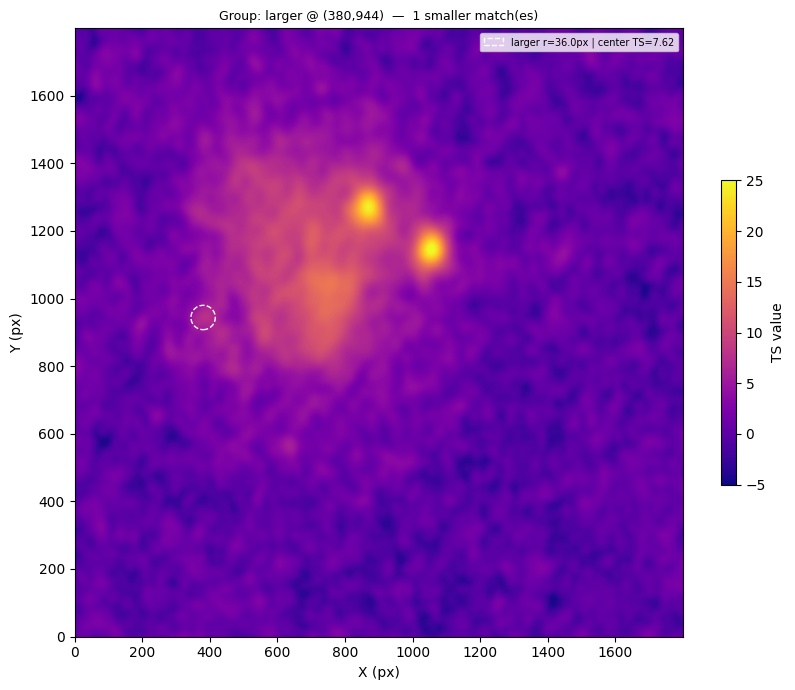

Plotting larger blob at (633, 563) with radius 36.0px and center intensity 5.90


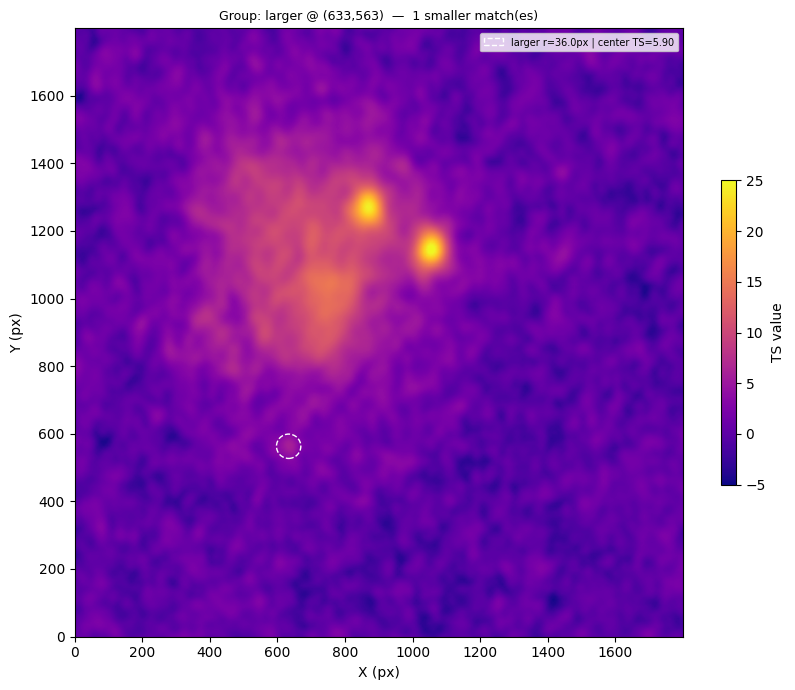

Plotting larger blob at (867, 1270) with radius 36.0px and center intensity 24.39


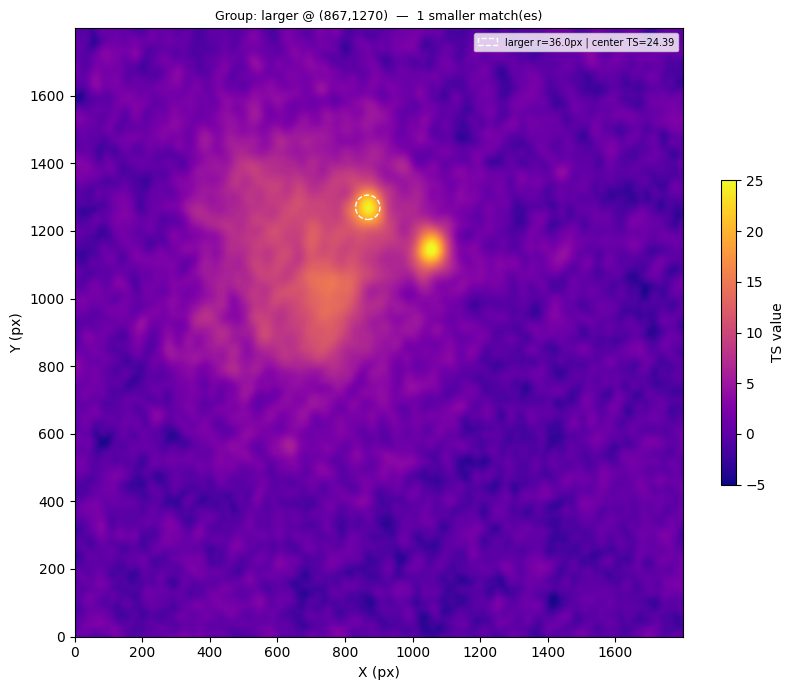

Plotting larger blob at (1053, 1146) with radius 36.0px and center intensity 25.50


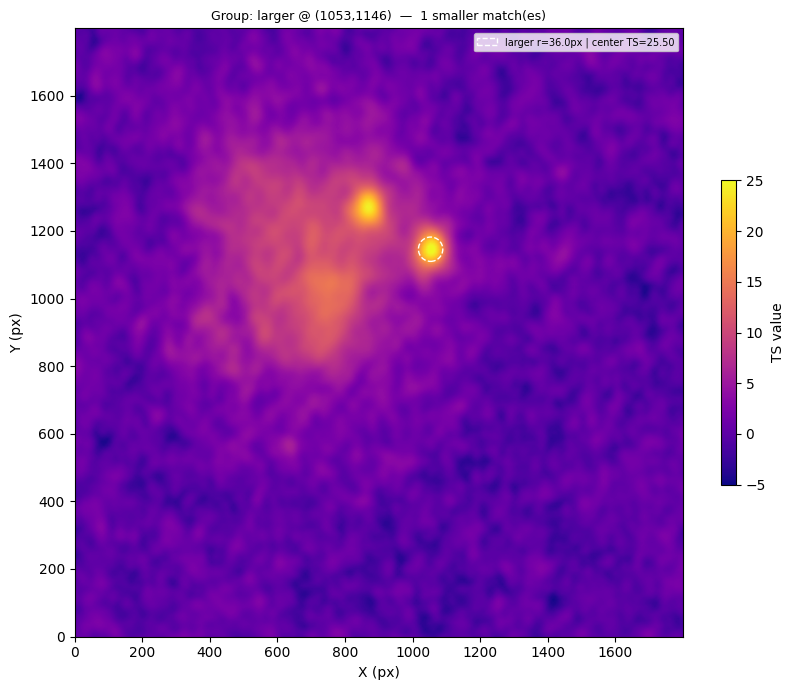

Plotting larger blob at (737, 883) with radius 36.0px and center intensity 11.78


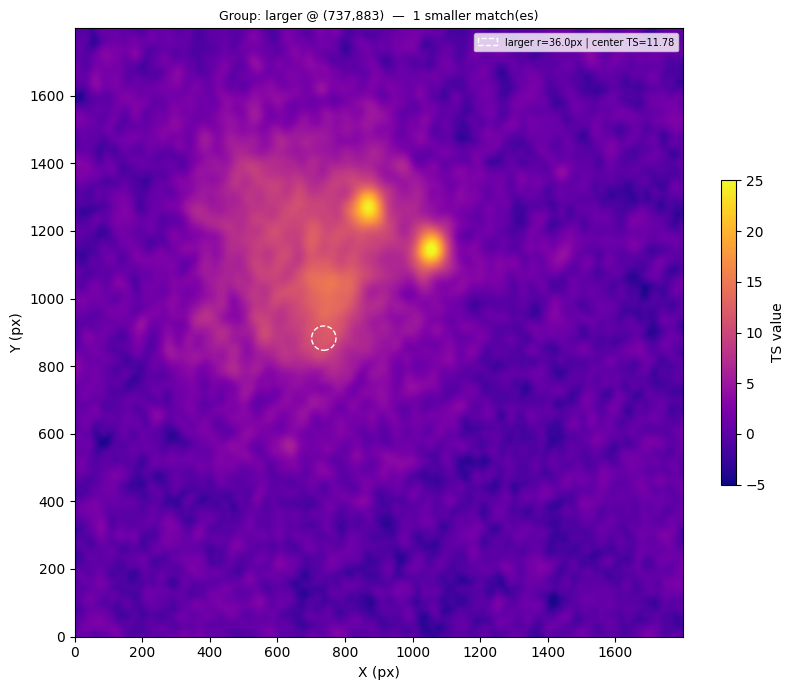

In [ ]:
for lb, sbs in groups:
    flag=0
    if lb is None:
        # standalone smaller blob — use it as the background
        flag=1
        sb, _ = sbs[0]
        sy, sx, sr = sb
        lb_patch = (int(sy), int(sx), sr)
        ly, lx, lr = lb_patch
    else:
        ly, lx, lr = lb
        ly, lx = int(ly), int(lx)

    
    y_min = int(max(ly - lr, 0))
    y_max = int(min(ly + lr, array.shape[0]))
    x_min = int(max(lx - lr, 0))
    x_max = int(min(lx + lr, array.shape[1]))

    patch = array[y_min:y_max, x_min:x_max]

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(array, origin='lower', cmap='plasma', interpolation='nearest', vmin=-5, vmax=25)
    plt.colorbar(im, label='TS value' ,fraction=0.046, pad=0.04, shrink=0.5)

    center_intensity_lb = array[ly, lx]
    print(f"Plotting larger blob at ({lx}, {ly}) with radius {lr:.1f}px and center intensity {center_intensity_lb:.2f}")
    circle_l = plt.Circle((lx, ly), lr, fill=False,
                           edgecolor='white', linewidth=1, linestyle='--',
                           label=f'larger r={lr:.1f}px | center TS={center_intensity_lb:.2f}')
    ax.add_patch(circle_l)
    colors = plt.cm.cool(np.linspace(0, 1, len(sbs)))
    for (sb, frac), color in zip(sbs, colors):
        sy, sx, sr = sb
        sy, sx = int(sy), int(sx)
        center_intensity_sb = array[sy, sx]

        dist     = np.sqrt((sy - ly)**2 + (sx - lx)**2)
        relation = "inside" if dist + sr <= lr else "overlap/touch"

        # bright pixels within smaller blob
        y_min_s = int(max(sy - sr, 0))
        y_max_s = int(min(sy + sr, array.shape[0]))
        x_min_s = int(max(sx - sr, 0))
        x_max_s = int(min(sx + sr, array.shape[1]))

        yy, xx      = np.mgrid[y_min_s:y_max_s, x_min_s:x_max_s]
        dist_mask   = np.sqrt((yy - sy)**2 + (xx - sx)**2)
        mask_circle = dist_mask <= sr
        mask        = mask_circle & (array[y_min_s:y_max_s, x_min_s:x_max_s] > center_intensity_sb)

        bright_ys = yy[mask]
        bright_xs = xx[mask]

        # ax.scatter(bright_xs, bright_ys, s=10, color=color, alpha=0.3)
        if flag is 0:
            # ax.scatter(sx, sy, s=80, color=color, marker='*', zorder=5)
            print(f"    Plotting smaller blob at ({sx}, {sy}) with radius {sr:.1f}px and center intensity {center_intensity_sb:.2f} — {relation} with larger blob")
            circle_s = plt.Circle((sx, sy), sr, fill=False,
                                edgecolor=color, linewidth=1, linestyle='--',
                                label=f'smaller ({relation}) r={sr:.1f}px | center TS={center_intensity_sb:.2f}')
            ax.add_patch(circle_s)

    # ax.set_xlim(x_min, x_max)
    # ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'Group: larger @ ({lx},{ly})  —  {len(sbs)} smaller match(es)', fontsize=9)
    ax.set_xlabel('X (px)')
    ax.set_ylabel('Y (px)')
    plt.tight_layout()
    plt.show()

Larger blob @ (706,1129) r=144.0px TS=11.53 — 1 smaller blob(s)

Intensity Fraction of pixels greater than 5 sigma detection threshold = 100.0%
Larger blob galactic coordinates: l=190.813°, b=54.163° with center TS=11.53, radius=0.8 deg
  deltaTS -2.7298962522220194 of Ext-PS 
  Smaller blob with r=36.0px TS=14.26 | sep=0.639° | ΔTS=2.73
  Both circles overlap
  tagged for ps pool due to sep > 0.4°

  All smaller blobs are within 0.3° of the larger blob @ (706,1129)


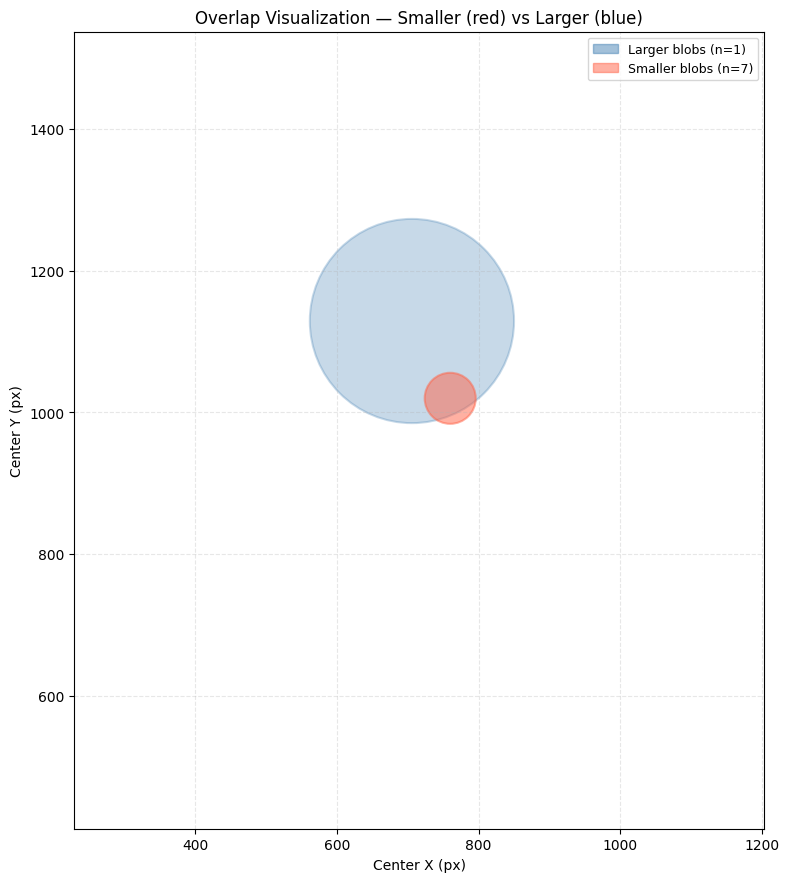







Length of Kept PS candidates = 7
Length of Kept Ext candidates = 1
Length of Removed PS candidates = 0
Length of Removed Ext candidates = 0


In [ ]:
ps_filtered_group = []
ext_filtered_group = []
ps_removed_group = []
ext_removed_group = []
fig=None

def compute_bright_frac(testimage, ly, lx, lr):
    """Fraction of pixels within the blob circle brighter than the center pixel."""
    y_min = int(max(ly - lr, 0))
    y_max = int(min(ly + lr, testimage.shape[0]))
    x_min = int(max(lx - lr, 0))
    x_max = int(min(lx + lr, testimage.shape[1]))

    yy, xx      = np.mgrid[y_min:y_max, x_min:x_max]
    dist        = np.sqrt((yy - ly)**2 + (xx - lx)**2)
    mask_circle = dist <= lr
    mask_bright = mask_circle & (testimage[y_min:y_max, x_min:x_max] > 5)

    return mask_bright.sum() / mask_circle.sum()

def calculate_separation(coord1, coord2):
    """Calculate angular separation in degrees between two SkyCoord objects."""
    return coord1.separation(coord2).deg

def circle_overlap(coord1, r1, coord2, r2, pixel_size):
    """Check if two circles overlap."""
    dist_between_center = calculate_separation(coord1, coord2)
    radii_sum = r1 + r2
    if dist_between_center > radii_sum * pixel_size and dist_between_center > abs(r1 - r2) * pixel_size:
        return 0.0 # Overlap
    elif dist_between_center < abs(r1 - r2) * pixel_size:
        return 1.0 # One circle is inside the other

for lb, sbs in groups:
    tag_ps=0
    tag_ex=0
    ps_flagged = []
    if lb is None:
        # Add all smaller blobs to ps pool if no larger blob
        for sb, frac in sbs:
                ps_filtered_group.append(sb)
        print()

    else:
        ly, lx, lr = lb
        ly, lx = int(ly), int(lx)

        center_intensity_lb = array[ly, lx]
        print(f"Larger blob @ ({lx},{ly}) r={lr:.1f}px TS={center_intensity_lb:.2f} — {len(sbs)} smaller blob(s)")
        bright_frac = compute_bright_frac(array, ly, lx, lr)
        print()
        print(f"Intensity Fraction of pixels greater than 5 sigma detection threshold = {100*bright_frac:.1f}%")

        if bright_frac < 0.5:
            print("Larger blob is artifact of blob detection")
            tag_ex += 1
            for sb, frac in sbs:
                ps_flagged.append(sb)
        else:
            if len(sbs) == 0:
                print(f"Larger blob @ ({lx},{ly}) r={lr:.1f}px TS={array[ly, lx]:.2f} — no smaller blobs")
                print(f"Adding Larger blob galactic coordinates: l={coord_lb.l.deg:.3f}°, b={coord_lb.b.deg:.3f}° with center TS={center_intensity_lb:.2f}, radius={lr*pixel_size:.1f} deg")
                ext_filtered_group.append(lb)
                continue
            elif len(sbs) > 2:
                print(f"Larger blob @ ({lx},{ly}) r={lr:.1f}px TS={array[ly, lx]:.2f} overlaps 3 or more point blobs")
                print("Removing all point like blobs")
                print(f"Adding Larger blob galactic coordinates: l={coord_lb.l.deg:.3f}°, b={coord_lb.b.deg:.3f}° with center TS={center_intensity_lb:.2f}, radius={lr*pixel_size:.1f} deg")
                ext_filtered_group.append(lb)
            else:
                coord_lb = astropy_utils.pixel_to_skycoord(lx, ly, wcs=wcs).galactic
                print(f"Larger blob galactic coordinates: l={coord_lb.l.deg:.3f}°, b={coord_lb.b.deg:.3f}° with center TS={center_intensity_lb:.2f}, radius={lr*pixel_size:.1f} deg")

                fig, ax = plt.subplots(figsize=(8, 14))  
                circle = patches.Circle((lx, ly), lr, linewidth=1.5,
                                                edgecolor='steelblue', facecolor='steelblue', alpha=0.3)
                ax.add_patch(circle)

                for sb, frac in sbs:
                    sy, sx, sr = sb
                    sy, sx = int(sy), int(sx)
                    center_intensity_sb = array[sy, sx]
                    coord_sb = astropy_utils.pixel_to_skycoord(sx, sy, wcs=wcs).galactic
                    sep_deg  = calculate_separation(coord_lb, coord_sb)
                    overlap  = circle_overlap(coord_lb, lr, coord_sb, sr, pixel_size)
                    delta_ts    = float(array[ly, lx]) - float(array[sy, sx])
                    print(f"  deltaTS {delta_ts} of Ext-PS ")
                    if sep_deg < 0.1:
                        tag_ex +=1
                        ps_flagged.append(sb)
                        continue
                    if overlap == None:
                        print(f"  Smaller blob with r={sr:.1f}px TS={center_intensity_sb:.2f} | sep={sep_deg:.3f}° | ΔTS={center_intensity_sb - center_intensity_lb:.2f}")
                        print("  Both circles overlap")
                        if sep_deg > 0.4:
                            print("  tagged for ps pool due to sep > 0.4°")
                            tag_ps += 1
                            ps_flagged.append(sb)
                        else:
                            if delta_ts < 9:
                                tag_ex+=1
                                ps_flagged.append(sb)
                                print(f"  EXT Removed from ex pool due to deltaTS {delta_ts} > 5 ")
                            else:
                                ps_removed_group.append(sb)
                                print("  Removed from ps pool due to sep <= 0.4°")

                    elif overlap == 1:
                        print(f"  Smaller blob with r={sr:.1f}px TS={center_intensity_sb:.2f} | sep={sep_deg:.3f}° | ΔTS={center_intensity_sb - center_intensity_lb:.2f}")
                        print("  One circle is inside the other")
                        if sep_deg > 0.3 and delta_ts >= 9:
                            print(f"  tagged for ps pool due to sep > 0.3° and ΔTS(EXT-PS) {delta_ts} <= 9")
                            tag_ps += 1
                            tag_ex += 1
                            ps_flagged.append(sb)
                        elif (center_intensity_sb - center_intensity_lb) >= 9:
                            print(f"  tagged for ps pool due to ΔTS(EXT-PS) {delta_ts} <= 9")
                            tag_ps += 1
                            ps_flagged.append(sb)
                        else:
                            print("  Removed from ps pool due to sep <= 0.3°")
                            ps_removed_group.append(sb)

                    circle = patches.Circle((sx, sy), sr, linewidth=1.5,
                                            edgecolor='tomato', facecolor='tomato', alpha=0.5)
                    ax.add_patch(circle)


            print()
        if tag_ex > 0:
            ext_removed_group.append(lb)
        else:
            ext_filtered_group.append(lb)
        if tag_ps == len(sbs):
                ###Add all smaller blobs to ps pool
                print(f"  All smaller blobs are within 0.3° of the larger blob @ ({lx},{ly})")

        for j in ps_flagged:
            ps_filtered_group.append(j)

        legend_handles = [
            patches.Patch(facecolor='steelblue', edgecolor='steelblue', alpha=0.5, label=f'Larger blobs (n={len(final_ext_blobs)})'),
            patches.Patch(facecolor='tomato',    edgecolor='tomato',    alpha=0.5, label=f'Smaller blobs (n={len(final_ps_blobs)})'),
        ]
        if fig:
            ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
            margin = 150
            ax.set_ylim(all_blobs[:, 0].min() - margin, all_blobs[:, 0].max() + margin)
            ax.set_xlim(all_blobs[:, 1].min() - margin, all_blobs[:, 1].max() + margin)

            ax.set_aspect('equal')
            ax.set_xlabel('Center X (px)')
            ax.set_ylabel('Center Y (px)')
            ax.set_title('Overlap Visualization — Smaller (red) vs Larger (blue)')
            ax.grid(True, linestyle='--', alpha=0.3)

            plt.tight_layout()
            plt.show()
        # print("\n")



print(f"Length of Kept PS candidates = {len(ps_filtered_group)}")
print(f"Length of Kept Ext candidates = {len(ext_filtered_group)}")
print(f"Length of Removed PS candidates = {len(ps_removed_group)}")
print(f"Length of Removed Ext candidates = {len(ext_removed_group)}")

In [ ]:
print(f"Length of Kept PS candidates = {len(ps_filtered_group)}")
print(f"Length of Kept Ext candidates = {len(ext_filtered_group)}")
print(f"Length of Removed PS candidates = {len(ps_removed_group)}")
print(f"Length of Removed Ext candidates = {len(ext_removed_group)}")

def deduplicate_ps_group(ps_filtered_group, wcs, sep_threshold_deg=0.4):
    """
    Remove smaller PS blobs from ps_filtered_group when two blobs are
    within sep_threshold_deg of each other, keeping the larger one.

    Parameters
    ----------
    ps_filtered_group : list of (y, x, r) tuples
    array             : significance map (for TS lookup)
    wcs               : WCS object
    pixel_size        : degrees per pixel
    sep_threshold_deg : angular separation threshold in degrees

    Returns
    -------
    kept    : list of blobs that survived
    removed : list of blobs that were culled
    """
    if len(ps_filtered_group) <= 1:
        return list(ps_filtered_group), []
    
    blobs = []
    for item in ps_filtered_group:
        try:
            y, x, r = item
            blobs.append((y, x, r))
        except (TypeError, ValueError):
            y, x, r = item[0][0]
            blobs.append((y, x, r))

    blobs = sorted(blobs, key=lambda b: b[2], reverse=True)

    keep_mask = [True] * len(blobs)

    for i in range(len(blobs)):
        if not keep_mask[i]:
            continue
        yi, xi, ri = blobs[i]
        coord_i    = astropy_utils.pixel_to_skycoord(int(xi), int(yi), wcs=wcs).galactic

        for j in range(i + 1, len(blobs)):
            if not keep_mask[j]:
                continue
            yj, xj, rj = blobs[j]
            coord_j     = astropy_utils.pixel_to_skycoord(int(xj), int(yj), wcs=wcs).galactic
            sep         = calculate_separation(coord_i, coord_j)
            print(f" Separation between points = {sep}")
            if sep < sep_threshold_deg:
                print(f"  PS dedup: removing smaller blob @ ({xj},{yj}) r={rj:.1f}px "
                      f"sep={sep:.3f}° < {sep_threshold_deg}° threshold")
                keep_mask[j] = False

    kept    = [b for b, k in zip(blobs, keep_mask) if     k]
    removed = [b for b, k in zip(blobs, keep_mask) if not k]
    print(f"  PS dedup: {len(blobs)} → {len(kept)} kept, {len(removed)} removed")
    return kept, removed
ps_filtered_group, ps_dedup_removed = deduplicate_ps_group(
    ps_filtered_group, wcs, sep_threshold_deg=0.4
)
ext_filtered_group, ps_dedup_removed = deduplicate_ps_group(
    ext_filtered_group, wcs, sep_threshold_deg=0.4
)
ext_removed_group.extend(ps_dedup_removed)

print(f"Final — PS kept: {len(ps_filtered_group)}  EXT kept: {len(ext_filtered_group)}")
print(f"        PS removed: {len(ps_removed_group)}  EXT removed: {len(ext_removed_group)}")

Length of Kept PS candidates = 7
Length of Kept Ext candidates = 1
Length of Removed PS candidates = 0
Length of Removed Ext candidates = 0
 Separation between points = 2.366990620506847
 Separation between points = 2.3753890722398405
 Separation between points = 2.416606216572244
 Separation between points = 1.414065243262138
 Separation between points = 1.9146358650264024
 Separation between points = 0.6997819433047446
 Separation between points = 2.3734726206351344
 Separation between points = 4.182584152428996
 Separation between points = 2.231439396963479
 Separation between points = 3.5142917232778252
 Separation between points = 2.860943662383948
 Separation between points = 2.4631850958908057
 Separation between points = 3.41848184746186
 Separation between points = 4.27377553424376
 Separation between points = 2.2239680750805086
 Separation between points = 3.8199350223294672
 Separation between points = 3.9015610660416815
 Separation between points = 1.7246369591634236
 Separ

In [ ]:
def custom_sources_plot(names, ra, dec, ext, ax, wcs, npix):
    for i in range(len(names)):
        coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
        pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
        ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
        # ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=7, xytext=(100, -90), 
        # textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='white', linewidth=2, 
        # linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
        # path_effects=[pe.withStroke(linewidth=2, foreground="white")])
        r = ext[i] / npix
        c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='white', linewidth=3, fill=False)
        ax.add_patch(c)
        if r > 50:
            ax.text(pixelcoord[0], pixelcoord[1] - r -45, f"FN  {names[i]}",
            color='white', fontsize=10, ha='center', zorder=7)
        else:
            ax.text(pixelcoord[0], pixelcoord[1] - 50, f"FN  {names[i]}",
            color='white', fontsize=10, ha='center', zorder=7)

Plotting contours [ 5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25.]


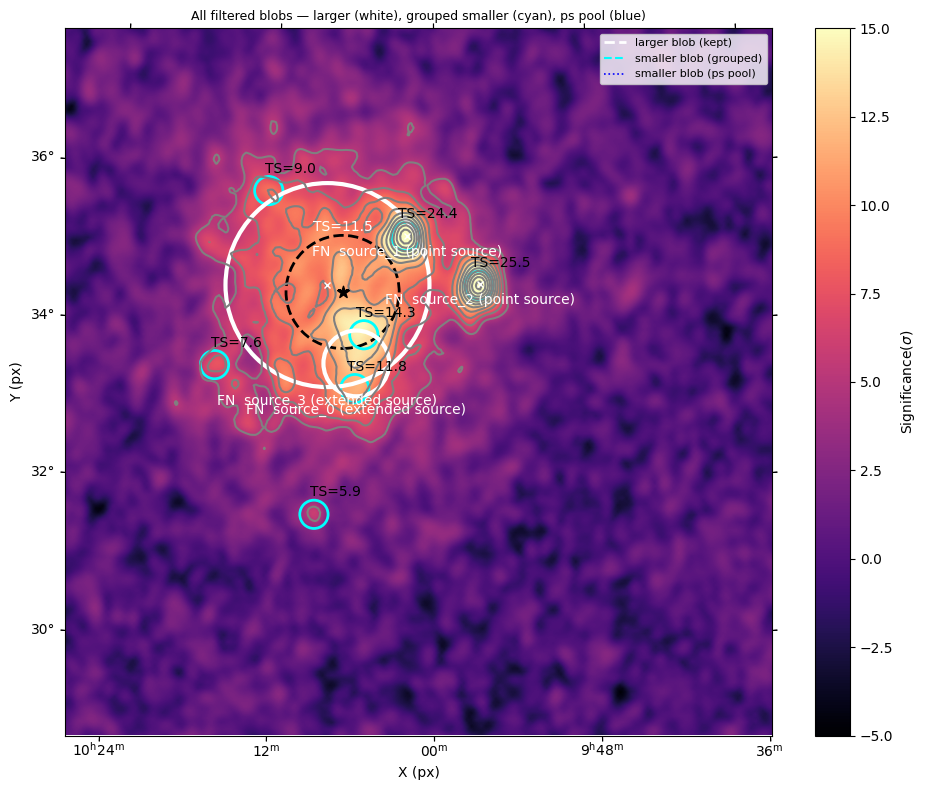

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(array, cmap='magma', vmin=-5, vmax=15)
plt.colorbar(im, ax=ax, label=r'Significance($\sigma$)', fraction=0.046, pad=0.04)
# ── larger blobs from filtered_groups ────────────────────────────────────────
for lb in ext_filtered_group:
    ly, lx, lr = lb
    ly, lx = int(ly), int(lx)
    center_intensity_lb = array[ly, lx]

    circle_l = plt.Circle((lx, ly), lr, fill=False,
                           edgecolor='black', linewidth=2.0, linestyle='--')
    ax.add_patch(circle_l)
    ax.scatter(lx, ly, s=80, c='black', marker='*', zorder=5)
    ax.text(lx, ly + lr + 10, f'TS={center_intensity_lb:.1f}',
            color='white', fontsize=10, ha='center')


# ── standalone smaller blobs in ps_filtered_group ────────────────────────────
for sb in ps_filtered_group:
    # print(sb[0][0])
    try:
        sy, sx, sr = sb
    except:
        sy, sx, sr = sb[0][0]
    sy, sx = int(sy), int(sx)
    center_intensity_sb = array[sy, sx]
    circle_s = plt.Circle((sx, sy), sr, fill=False,
                           edgecolor='cyan', linewidth=2, linestyle='-')
    ax.add_patch(circle_s)
    # ax.scatter(sx, sy, s=60, c='blue', marker='*', zorder=5)
    ax.text(sx + sr + 20, sy + sr + 10, f'TS={center_intensity_sb:.1f}',
            color='black', fontsize=10, ha='center')
    # ax.text(sx + sr + 2, sy, f'TS={center_intensity_sb:.1f}',
    #         color='blue', fontsize=6, ha='center')

# ── legend handles ────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='white',  linewidth=2,   linestyle='--', label='larger blob (kept)'),
    Line2D([0], [0], color='cyan',   linewidth=1.5, linestyle='--', label='smaller blob (grouped)'),
    Line2D([0], [0], color='blue',   linewidth=1.2, linestyle=':',  label='smaller blob (ps pool)'),
]
levels = np.arange(5, np.max(array), 2)
print(f"Plotting contours {levels}")
hi_transform = ax.get_transform(wcs)
ax.contour(array, levels=levels, transform=hi_transform, colors='gray')
# plot_4hwc1D(ax, wcs, pixel_size)
labelA = injected_sources['Name']
raA = injected_sources['ra']
decA = injected_sources['dec']
extA = injected_sources['ext']
custom_sources_plot(labelA, raA, decA, extA, ax, wcs, pixel_size)

ax.set_xlim(0, xnum)
ax.set_ylim(0, ynum)
ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
ax.set_title('All filtered blobs — larger (white), grouped smaller (cyan), ps pool (blue)', fontsize=9)
ax.set_xlabel('X (px)')
ax.set_ylabel('Y (px)')
plt.tight_layout()
plt.show()


  Match radius : 0.5°
  Injected sources : 4
  Detected blobs   : 8
───────────────────────────────────────────────────────
  TP  (matched)    : 4
  FP  (spurious)   : 4
  FN  (missed)     : 0
  NN  (no detect.) : False
───────────────────────────────────────────────────────
  Precision        : 0.500
  Recall           : 1.000
  F1 score         : 0.667

  TP  src=source_0 (extended source)  blob_type=PS  sep=0.322°  TS=11.8
  TP  src=source_1 (point source)  blob_type=PS  sep=0.018°  TS=24.4
  TP  src=source_2 (point source)  blob_type=PS  sep=0.019°  TS=25.5
  TP  src=source_3 (extended source)  blob_type=EXT  sep=0.253°  TS=11.5
  FP  blob @ (760,1020)  type=PS  TS=14.3
  FP  blob @ (518,1387)  type=PS  TS=9.0
  FP  blob @ (380,944)  type=PS  TS=7.6
  FP  blob @ (633,563)  type=PS  TS=5.9


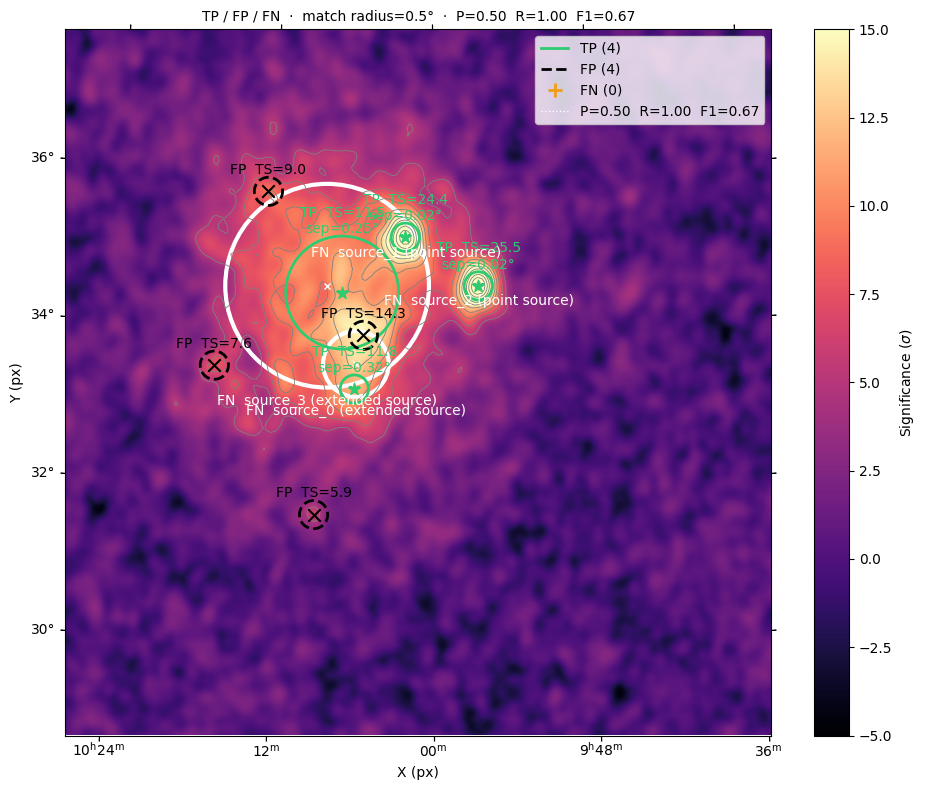

In [ ]:
def match_blobs_to_sources(ext_filtered_group, ps_filtered_group,
                            injected_sources, array, wcs, pixel_size,
                            match_radius_deg=0.4):
    """
    Match detected blobs against injected sources.

    Parameters
    ----------
    ext_filtered_group : list of (y, x, r) — extended blobs
    ps_filtered_group  : list of (y, x, r) or nested — point source blobs
    injected_sources   : dict/DataFrame with 'Name', 'ra', 'dec', 'ext'
    match_radius_deg   : angular match tolerance in degrees

    Returns
    -------
    results : dict with tp/fp/fn/nn lists and metrics
    """
    import astropy.wcs.utils as astropy_utils
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # ── Normalise all detected blobs into a flat list ─────────────────────────
    detected = []
    for lb in ext_filtered_group:
        ly, lx, lr = lb
        coord = astropy_utils.pixel_to_skycoord(int(lx), int(ly), wcs=wcs)
        detected.append({
            'y': int(ly), 'x': int(lx), 'r': lr,
            'coord': coord,
            'ra':  coord.ra.deg, 'dec': coord.dec.deg,
            'ts':  float(array[int(ly), int(lx)]),
            'type': 'EXT',
        })

    for sb in ps_filtered_group:
        try:
            sy, sx, sr = sb
        except (TypeError, ValueError):
            sy, sx, sr = sb[0][0]
        coord = astropy_utils.pixel_to_skycoord(int(sx), int(sy), wcs=wcs)
        detected.append({
            'y': int(sy), 'x': int(sx), 'r': sr,
            'coord': coord,
            'ra':  coord.ra.deg, 'dec': coord.dec.deg,
            'ts':  float(array[int(sy), int(sx)]),
            'type': 'PS',
        })

    # ── Normalise injected sources into a flat list ───────────────────────────
    names = injected_sources['Name'] if hasattr(injected_sources['Name'], '__iter__') and not isinstance(injected_sources['Name'], str) else [injected_sources['Name']]
    ras   = injected_sources['ra']   if hasattr(injected_sources['ra'],   '__iter__') else [injected_sources['ra']]
    decs  = injected_sources['dec']  if hasattr(injected_sources['dec'],  '__iter__') else [injected_sources['dec']]
    exts  = injected_sources['ext']  if hasattr(injected_sources['ext'],  '__iter__') else [injected_sources['ext']]

    sources = []
    for name, ra, dec, ext in zip(names, ras, decs, exts):
        sources.append({
            'name': name, 'ra': float(ra), 'dec': float(dec),
            'ext':  float(ext),
            'coord': SkyCoord(ra=float(ra)*u.deg, dec=float(dec)*u.deg),
        })

    # ── Greedy nearest-neighbour matching ─────────────────────────────────────
    matched_blob_ids   = set()
    matched_source_ids = set()

    tp_pairs = []   # (source, blob, sep_deg)

    for si, src in enumerate(sources):
        best_sep, best_bi, best_blob = np.inf, None, None
        for bi, blob in enumerate(detected):
            if bi in matched_blob_ids:
                continue
            sep = src['coord'].separation(blob['coord']).deg
            if sep < best_sep:
                best_sep, best_bi, best_blob = sep, bi, blob
        if best_blob is not None and best_sep <= match_radius_deg:
            tp_pairs.append({'source': src, 'blob': best_blob,
                             'sep_deg': best_sep})
            matched_blob_ids.add(best_bi)
            matched_source_ids.add(si)

    tp_sources = [p['source'] for p in tp_pairs]
    tp_blobs   = [p['blob']   for p in tp_pairs]
    fp_blobs   = [b for bi, b in enumerate(detected) if bi not in matched_blob_ids]
    fn_sources = [s for si, s in enumerate(sources)  if si not in matched_source_ids]

    # NN — no blobs at all (neither TP nor FP detected anywhere in the map)
    nn = len(detected) == 0

    precision = len(tp_blobs) / len(detected)         if detected  else float('nan')
    recall    = len(tp_sources) / len(sources)         if sources   else float('nan')
    f1        = (2*precision*recall / (precision+recall)
                 if (precision + recall) > 0 else float('nan'))

    return {
        'tp_pairs':   tp_pairs,
        'tp_sources': tp_sources,
        'tp_blobs':   tp_blobs,
        'fp_blobs':   fp_blobs,
        'fn_sources': fn_sources,
        'nn':         nn,
        'n_detected': len(detected),
        'n_sources':  len(sources),
        'precision':  precision,
        'recall':     recall,
        'f1':         f1,
        'match_radius_deg': match_radius_deg,
    }


# ── Run matching ──────────────────────────────────────────────────────────────
match_results = match_blobs_to_sources(
    ext_filtered_group, ps_filtered_group,
    injected_sources, array, wcs, pixel_size,
    match_radius_deg=0.5,
)

print(f"\n{'='*55}")
print(f"  Match radius : {match_results['match_radius_deg']}°")
print(f"{'='*55}")
print(f"  Injected sources : {match_results['n_sources']}")
print(f"  Detected blobs   : {match_results['n_detected']}")
print(f"{'─'*55}")
print(f"  TP  (matched)    : {len(match_results['tp_blobs'])}")
print(f"  FP  (spurious)   : {len(match_results['fp_blobs'])}")
print(f"  FN  (missed)     : {len(match_results['fn_sources'])}")
print(f"  NN  (no detect.) : {match_results['nn']}")
print(f"{'─'*55}")
print(f"  Precision        : {match_results['precision']:.3f}")
print(f"  Recall           : {match_results['recall']:.3f}")
print(f"  F1 score         : {match_results['f1']:.3f}")
print(f"{'='*55}\n")
for p in match_results['tp_pairs']:
    print(f"  TP  src={p['source']['name']:20s}  "
          f"blob_type={p['blob']['type']}  "
          f"sep={p['sep_deg']:.3f}°  TS={p['blob']['ts']:.1f}")
for b in match_results['fp_blobs']:
    print(f"  FP  blob @ ({b['x']},{b['y']})  type={b['type']}  TS={b['ts']:.1f}")
for s in match_results['fn_sources']:
    print(f"  FN  src={s['name']:20s}  ra={s['ra']:.3f}°  dec={s['dec']:.3f}°")


# ── Overlay TP / FP / FN annotations on the existing map ─────────────────────
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection=wcs)
im  = ax.imshow(array, cmap='magma', vmin=-5, vmax=15)
plt.colorbar(im, ax=ax, label=r'Significance ($\sigma$)', fraction=0.046, pad=0.04)

levels = np.arange(5, np.max(array), 2)
hi_transform = ax.get_transform(wcs)
ax.contour(array, levels=levels, transform=hi_transform, colors='gray', linewidths=0.6)

# TP blobs — green
for p in match_results['tp_pairs']:
    b  = p['blob']
    ax.add_patch(plt.Circle((b['x'], b['y']), b['r'],
                             fill=False, edgecolor='#2ECC71',
                             linewidth=2, linestyle='-', zorder=5))
    ax.scatter(b['x'], b['y'], s=80, c='#2ECC71', marker='*', zorder=6)
    ax.text(b['x'], b['y'] + b['r'] + 8,
            f"TP  TS={b['ts']:.1f}\nsep={p['sep_deg']:.2f}°",
            color='#2ECC71', fontsize=10, ha='center', zorder=7)

# FP blobs — red
for b in match_results['fp_blobs']:
    ax.add_patch(plt.Circle((b['x'], b['y']), b['r'],
                             fill=False, edgecolor='black',
                             linewidth=2, linestyle='--', zorder=5))
    ax.scatter(b['x'], b['y'], s=80, c='black', marker='x', zorder=6)
    ax.text(b['x'], b['y'] + b['r'] + 8,
            f"FP  TS={b['ts']:.1f}",
            color='black', fontsize=10, ha='center', zorder=7)

# FN sources — orange cross at true position
for s in match_results['fn_sources']:
    sx_px, sy_px = wcs.all_world2pix(s['ra'], s['dec'], 0)
    ax.scatter(sx_px, sy_px, s=200, c='#F39C12',
               marker='+', linewidths=2.5, zorder=6)
    ax.text(sx_px, sy_px + 12, f"FN  {s['name']}",
            color='#F39C12', fontsize=10, ha='center', zorder=7)

# Injected source circles (truth)
custom_sources_plot(
    injected_sources['Name'], injected_sources['ra'],
    injected_sources['dec'],  injected_sources['ext'],
    ax, wcs, pixel_size,
)

legend_handles = [
    Line2D([0],[0], color='#2ECC71', lw=2, ls='-',  label=f"TP ({len(match_results['tp_blobs'])})"),
    Line2D([0],[0], color='black', lw=2, ls='--', label=f"FP ({len(match_results['fp_blobs'])})"),
    Line2D([0],[0], color='#F39C12', lw=0, marker='+', markersize=10,
           markeredgewidth=2, label=f"FN ({len(match_results['fn_sources'])})"),
    Line2D([0],[0], color='white',   lw=1, ls=':',
           label=f"P={match_results['precision']:.2f}  "
                 f"R={match_results['recall']:.2f}  "
                 f"F1={match_results['f1']:.2f}"),
]
ax.set_xlim(0, xnum);  ax.set_ylim(0, ynum)
ax.legend(handles=legend_handles, fontsize=10, loc='upper right')
ax.set_title(f'TP / FP / FN  ·  match radius={match_results["match_radius_deg"]}°  '
             f'·  P={match_results["precision"]:.2f}  '
             f'R={match_results["recall"]:.2f}  '
             f'F1={match_results["f1"]:.2f}', fontsize=10)
ax.set_xlabel('X (px)');  ax.set_ylabel('Y (px)')
plt.tight_layout()
plt.show()